In [200]:
import torch
from torch import nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets
from torchvision.transforms import v2
import matplotlib.pyplot as plt

In [201]:
data = datasets.CIFAR10(
    root="data",
    train=True,
    download=True,
    transform=v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])
)

split_ratio = 0.9
train_size = int(split_ratio * len(data))
val_size = len(data) - train_size
train_data, val_data = random_split(data, [train_size, val_size])

test_data = datasets.CIFAR10(
    root="data",
    train=False,
    download=True,
    transform=v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])
)

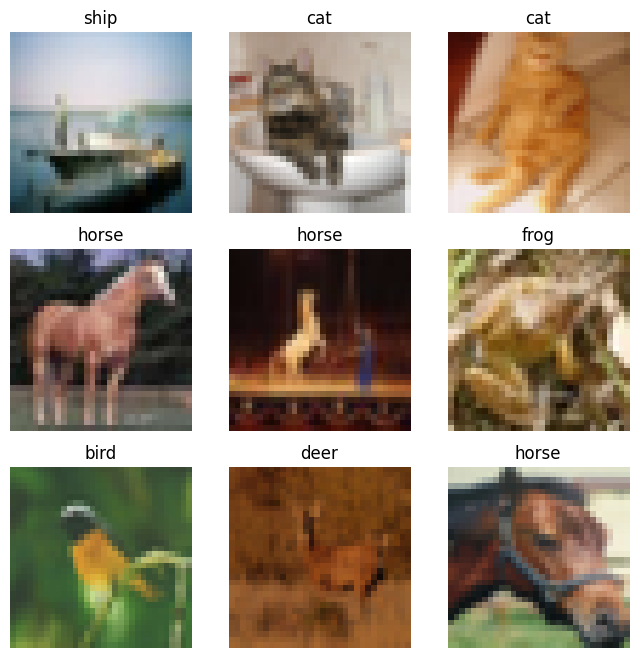

In [202]:
figure = plt.figure(figsize=(8, 8))
rows, cols = 3, 3

labels_map = {
    0: "airplane",
    1: "automobile",
    2: "bird",
    3: "cat",
    4: "deer",
    5: "dog",
    6: "frog",
    7: "horse",
    8: "ship",
    9: "truck"
}

for i in range(rows * cols):
    sample_idx = torch.randint(len(train_data), size=(1,)).item()
    img, label = train_data[sample_idx]
    figure.add_subplot(rows, cols, i + 1)
    plt.title(labels_map[label])
    plt.axis("off")
    plt.imshow(img.permute(1, 2, 0))
plt.show()

In [203]:
train_dataloader = DataLoader(train_data, batch_size=25, shuffle=True)
val_dataloader = DataLoader(val_data, batch_size=25, shuffle=False)
test_dataloader = DataLoader(test_data, batch_size=25, shuffle=False)

Feature batch shape: torch.Size([25, 3, 32, 32])
Labels batch shape: torch.Size([25])


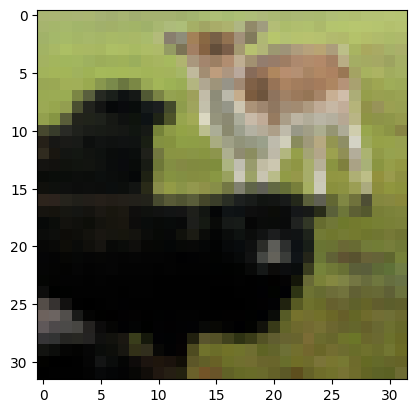

Labels: deer


In [204]:
train_features, train_labels = next(iter(train_dataloader))
print(f"Feature batch shape: {train_features.size()}")
print(f"Labels batch shape: {train_labels.size()}")
img = train_features[0]
plt.imshow(img.permute(1, 2, 0))
plt.show()
print(f"Labels: {labels_map[train_labels[0].item()]}")

In [205]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"

print(f"Using {device}")

Using mps


In [206]:
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(3072, 1024),
            nn.ReLU(),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Linear(512, 10)
        )
    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

In [207]:
model = NeuralNetwork().to(device)
print(model)

NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=3072, out_features=1024, bias=True)
    (1): ReLU()
    (2): Linear(in_features=1024, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=10, bias=True)
  )
)


In [208]:
X, y = next(iter(train_dataloader))

X = X.to(device)
y = y.to(device)

pred = model(X)

print(pred.shape)
print(y.shape)

torch.Size([25, 10])
torch.Size([25])


In [209]:
learning_rate = 1e-2
batch_size = 25
epochs = 20

In [210]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

In [211]:
def train_loop(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    model.train()
    num_batches = len(dataloader)
    train_loss, correct = 0, 0

    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)
        pred = model(X)
        loss = loss_fn(pred, y)

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        train_loss += loss.item()
        correct += (pred.argmax(1) == y).type(torch.float).sum().item()

        if batch % 100 == 0:
            loss, current = loss.item(), batch * batch_size + len(X)
            print(f"loss: {loss:>7f} [{current:>5d}/{size:>5d}]")
    train_loss /= num_batches
    correct /= size
    print(f"Train Error: \n Accuracy: {(100*correct):>0.1f}%, Avg train loss: {train_loss:>8f} \n")
    return train_loss, 100*correct

def val_loop(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    model.eval()
    num_batches = len(dataloader)
    val_loss, correct = 0, 0

    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            val_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()

    val_loss /= num_batches
    correct /= size
    print(f"Val Error: \n Accuracy: {(100*correct):>0.1f}%, Avg val loss: {val_loss:>8f} \n")
    return val_loss, 100*correct
    
def test_loop(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    model.eval()
    num_batches = len(dataloader)
    test_loss, correct = 0, 0

    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()

    test_loss /= num_batches
    correct /= size
    print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg test loss: {test_loss:>8f} \n")


In [212]:
import numpy as np

train_accuracy_history = np.zeros(epochs)
val_accuracy_history = np.zeros(epochs)
train_loss_history = np.zeros(epochs)
val_loss_history = np.zeros(epochs)

epoch_count = np.arange(1, epochs + 1)

In [213]:
for e in range(epochs):
    print(f"Epochs {e+1}\n--------------------------------------------")
    train_loss_history[e], train_accuracy_history[e] = train_loop(train_dataloader, model, loss_fn, optimizer)
    val_loss_history[e], val_accuracy_history[e] = val_loop(val_dataloader, model, loss_fn)
test_loop(test_dataloader, model, loss_fn)
print("DONE!")

Epochs 1
--------------------------------------------
loss: 2.306757 [   25/45000]
loss: 2.252383 [ 2525/45000]
loss: 2.179407 [ 5025/45000]
loss: 2.212621 [ 7525/45000]
loss: 2.042516 [10025/45000]
loss: 2.010219 [12525/45000]
loss: 2.215818 [15025/45000]
loss: 2.291723 [17525/45000]
loss: 1.860232 [20025/45000]
loss: 1.989586 [22525/45000]
loss: 1.922826 [25025/45000]
loss: 1.959986 [27525/45000]
loss: 1.842699 [30025/45000]
loss: 1.826718 [32525/45000]
loss: 1.588124 [35025/45000]
loss: 1.732821 [37525/45000]
loss: 1.778736 [40025/45000]
loss: 1.724613 [42525/45000]
Train Error: 
 Accuracy: 28.0%, Avg train loss: 1.994372 

Val Error: 
 Accuracy: 35.0%, Avg val loss: 1.819014 

Epochs 2
--------------------------------------------
loss: 1.675939 [   25/45000]
loss: 1.872432 [ 2525/45000]
loss: 1.567141 [ 5025/45000]
loss: 1.706058 [ 7525/45000]
loss: 1.873050 [10025/45000]
loss: 1.962490 [12525/45000]
loss: 1.901902 [15025/45000]
loss: 2.092820 [17525/45000]
loss: 1.872408 [20025/45

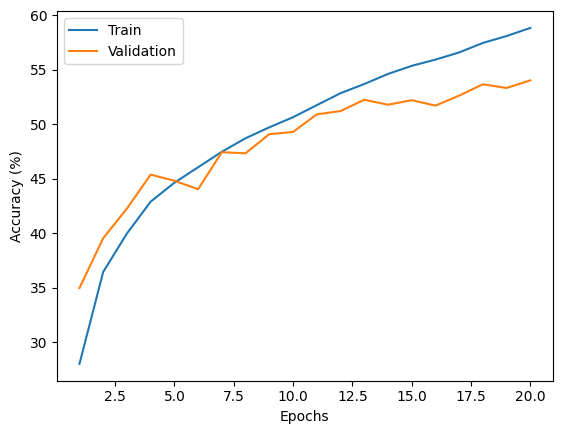

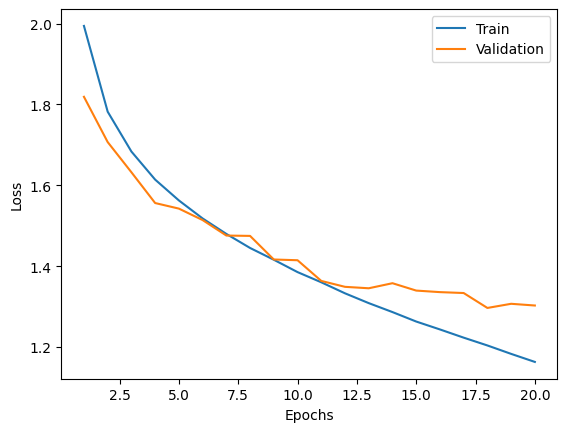

In [214]:
plt.plot(epoch_count, train_accuracy_history, label="Train")
plt.plot(epoch_count, val_accuracy_history, label="Validation")
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.legend()

plt.show()

plt.plot(epoch_count, train_loss_history, label="Train")
plt.plot(epoch_count, val_loss_history, label="Validation")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.show()